In [413]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

titanic = pandas.read_csv("../../conjuntos/titanic.csv")

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [414]:
y = titanic["Survived"]

x1 = (titanic["Pclass"] == 1).astype(int)
x1 = x1.fillna(x1.median())
x2 = (titanic["Pclass"] == 2).astype(int)
x2 = x2.fillna(x2.median())
x3 = (titanic["Sex"] == "female").astype(int)
x3 = x3.fillna(x3.median())
x4 = (titanic["Age"] - titanic["Age"].mean()) / titanic["Age"].std()
x4 = x4.fillna(x4.median())
x5 = titanic["SibSp"] + titanic["Parch"]
x5 = x5.fillna(x5.median())
x6 = ~titanic["Cabin"].isna()
x6 = x6.fillna(x6.median())

## Cubo de datos

In [415]:
X = numpy.array([
    numpy.zeros_like(x1) + 1,
    x1, x2, x3,
    x4, x5, x6,
]).T

pandas.DataFrame(X)

,0,1,2,3,4,5,6
0,1.0,0.0,0.0,0.0,-0.530005,1.0,0.0
1,1.0,1.0,0.0,1.0,0.571430,1.0,1.0
2,1.0,0.0,0.0,1.0,-0.254646,0.0,0.0
3,1.0,1.0,0.0,1.0,0.364911,1.0,1.0
4,1.0,0.0,0.0,0.0,0.364911,0.0,0.0
...,...,...,...,...,...,...,...
886,1.0,0.0,1.0,0.0,-0.185807,0.0,0.0
887,1.0,1.0,0.0,1.0,-0.736524,0.0,1.0
888,1.0,0.0,0.0,1.0,-0.116967,3.0,0.0
889,1.0,1.0,0.0,0.0,-0.254646,0.0,1.0


### Partición de los datos de entrenamiento y pruebas

In [416]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=120)

print(f"X       -> {X.shape}")
print(f"X_train -> {X_train.shape}")
print(f"X_test  -> {X_test.shape}")

print()

print(f"y       -> {y.shape}")
print(f"y_train -> {y_train.shape}")
print(f"y_test  -> {y_test.shape}")

X       -> (891, 7)
X_train -> (771, 7)
X_test  -> (120, 7)

y       -> (891,)
y_train -> (771,)
y_test  -> (120,)


Observa que reservamos exactamente 120 muestras para las pruebas, piensa en algo entre el 10% y 20%

## Curva Logística

$$
\hat{y} = \phi(X_{d} \cdot \beta)
$$

Con $\phi(\cdot)$ como la función de activación o curva logística

$$
\phi(z) = \frac{e^{z}}{1 + e^{z}} = \frac{1}{1 + e^{-z}}
$$

donde $z = X_{d} \cdot \beta$ es el predictor lineal

### Optimizador ingenuo

In [464]:
betas_opt = numpy.random.normal(1, 0.1, X_train.shape[1]) 
    # X_train.shape[1] = 7 caracteristicas

betas1 = betas_opt.copy()

errores = []

for i in range(1_000):
    # Betas alternativas, las optimas mas una perturbacion
    betas_alt = (
        betas_opt + 
        numpy.random.normal(0, 0.1, X_train.shape[1])
    )

    # Prediccion del modelo con las betas optimas
    yp_opt = (
        numpy.exp(X_train.dot(betas_opt)) /
        (1 + numpy.exp(X_train.dot(betas_opt)))
    )

    # Prediccion del modelo con las betas alternativas
    yp_alt = (
        numpy.exp(X_train.dot(betas_alt)) /
        (1 + numpy.exp(X_train.dot(betas_alt)))
    )

    # Error de entropia cruzada para la prediccion
    # usando las betas optimas
    e_opt = -(
        y_train * numpy.log(yp_opt) +
        (1 - y_train) * numpy.log(1 - yp_opt)
    ).mean()

    # Error de entropia cruzada para la prediccion
    # usando las betas alternativas
    e_alt = -(
        y_train * numpy.log(yp_alt) +
        (1 - y_train) * numpy.log(1 - yp_alt)
    ).mean()

    # Actualizacion de las betas si hay mayor error
    # en la prediccion optima que en la alternativa
    if e_opt > e_alt:
        betas_opt = betas_alt
        e_opt = e_alt

    # Guardamos el historico de los errores optimos
    errores.append(e_opt)

betas2 = betas_opt.copy()

print("Error óptimo", e_opt)

pandas.DataFrame({
    "betas_inicio": betas1,
    "betas_final": betas2
})

Error óptimo 0.4415270881037421


,betas_inicio,betas_final
0,0.769437,-2.261825
1,1.124715,1.495584
2,1.034449,1.181339
3,0.833943,2.734199
4,0.987405,-0.435213
5,1.145616,-0.213520
6,1.087544,1.017915


<Axes: >

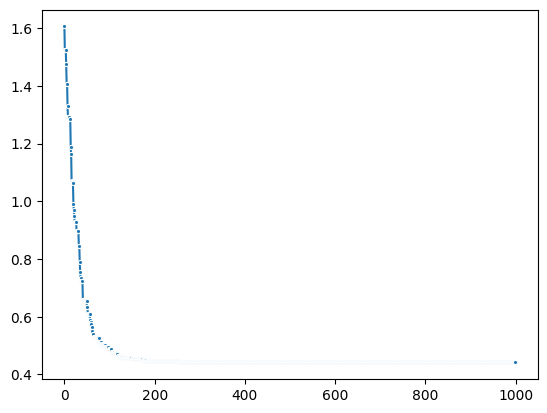

In [430]:
seaborn.lineplot(errores, marker=".")

Observamos un codo cercano a las 150 iteraciones, por lo que 200 iteraciones podrían ser suficientes para justificar que error ya no se reducirá más y no hay necesidad de incrementar las iteraciones.

Pero considera que los valores de perturbación son ingenuos y se podrían mejorar para cada beta ya que la matriz no está estandarizada.

In [468]:
pandas.DataFrame({
    "beta": betas_opt,
    "momios": numpy.exp(betas_opt),
    "momios_inv": numpy.exp(-betas_opt),
}).round(1)

,beta,momios,momios_inv
0,-2.3,0.1,9.6
1,1.5,4.5,0.2
2,1.2,3.3,0.3
3,2.7,15.4,0.1
4,-0.4,0.6,1.5
5,-0.2,0.8,1.2
6,1.0,2.8,0.4


### Validación de las predicciones

In [469]:
yp_test = (
    numpy.exp(X_test.dot(betas_opt)) /
    (1 + numpy.exp(X_test.dot(betas_opt)))
)

pandas.DataFrame({
    "y_test": y_test,
    "yp_test": yp_test,
    "yp_test_bin": (yp_test > 0.5).astype(int),
}).round(2)

,y_test,yp_test,yp_test_bin
280,0,0.03,0
643,1,0.10,0
362,0,0.45,0
641,1,0.96,1
129,0,0.06,0
...,...,...,...
384,0,0.10,0
432,1,0.74,1
121,0,0.10,0
501,0,0.68,1


> Matriz de confusión

<Axes: >

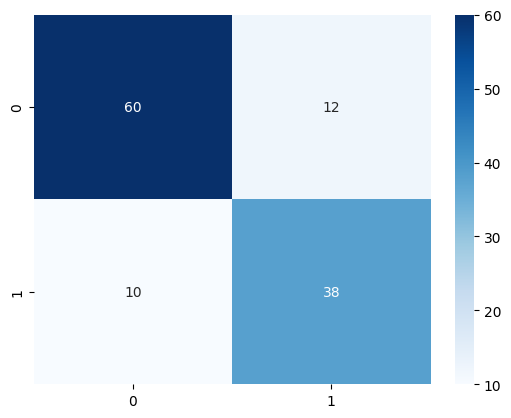

In [436]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, yp_test > 0.5)

seaborn.heatmap(
    matriz,
    cmap="Blues",
    annot=True
)

In [437]:
tn, fp, fn, tp = matriz.ravel()

print(f"TN: {tn:2d}")
print(f"FP: {fp:2d}")
print(f"FN: {fn:2d}")
print(f"TP: {tp:2d}")

TN: 60
FP: 12
FN: 10
TP: 38


In [438]:
accuracy = (tp + tn) / (tp + fp + fn + tn)
precision = tp / (tp + fp)
sensivity = tp / (tp + fn) # recall
specificity = tn / (tn + fp)
npv = tn / (tn + fn) # negative predictive value
f1 = 2 * (precision * sensivity) / (precision + sensivity) # f1-score

print(f"Exactitud     = {accuracy:.2f}")
print(f"Precision     = {precision:.2f}")
print(f"Sensibilidad  = {sensivity:.2f}")
print(f"Especificidad = {specificity:.2f}")
print(f"F1-Score      = {f1:.2f}")
print(f"NPV           = {npv:.2f}")

Exactitud     = 0.82
Precision     = 0.76
Sensibilidad  = 0.79
Especificidad = 0.83
F1-Score      = 0.78
NPV           = 0.86


- **Exactitud**: Indica el porcentaje de correctos positivos y negativos
- **Precisión**: Cuando la predicción es 1, indica el porcentaje de acierto
- **Sensibilidad**: Cuando el valor real es 1, indica el porcentaje de acierto
- **Especificidad**: Cuando el valor real es 0, indica el porcentaje de acierto
- **NPV**: Cuando la predicciónn es 0, indica el porcentaje de acierto
- **F1-Score**: Un balance entre predecir 1 y tener la razón y que el valor sea realmente 1 y tener la razón

**Interpretación**

El modelo es exacto en 82%, significa que si el modelo predice 0 o 1, más del 80% de las pruebas son correctamente clasificadas.

El modelo es preciso en 76%, significa que si el modelo predice 1, cerca del 76% de las pruebas estarán correctamente clasificadas.

El modelo es sensible en 79%, significa que si valor real es 1, cerca del 79% de las pruebas estarán correctamente clasificadas, esto significa que el modelo solo logra predecir cerca del 79% de los casos reales en 1.

El modelo es preciso negativamente en 83%, significa que si el modelo predice 0, cerca del 83% de las pruebas estarán correctamente clasificadas.

El modelo tiene un desempeño del 77%, significa que si valor real es 1 y la predicción también es 1, cerca del 77% de las pruebas estarán confirmando en promedio este resultado.

Por lo tanto, podemos observar que el modelo tiene un rendimiento de predicción estable del 77%, esto muestra una tendencia por clasificar mejor los negativos que los positivos, y se confirma con el 77% de sensibilidad, que indica que no es capaz de reconocer todas las veces que alguien sobrevive.

Por lo tanto:

Rendimento medio: 78%
Baja sensibilidad: 79% (no predice bien todos los casos de supervivencia)
Alta precisión negativa: 83% (el modelo se conforma con predecir mejor cuando no sobrevive)

Desbalance:

Hay 38 correctos + 12 incorrectos de casos reales 1, es decir, 50 casos donde hubo supervivencia, pero solo se clasifican 7% correctamente

Hay 60 correctos + 10 incorrectos de casos reales 0, es decir, 70 casos donde no hubo supervivencia, pero solo se clasifican 86% correctamente

Casos de supervivencia: 50 (76% bien clasificados)

Casos de no supervivencia: 70 (86% bien clasificados)

Balance de las pruebas: 40% supervivencia / 60% no supervivencia

En general las pruebas estuvieron balanceadas (cerca del 40% de observaciones en supervivencia y 60% no supervivencia), por lo que la credibilidad aumenta al no estar sesgado por observar muchas menos supervivencias que no supervivencias.

In [439]:
(y_test == 1).sum() / 120

np.float64(0.4)

### Cambiando el umbral

TN: 61
FP: 11
FN: 11
TP: 37

Exactitud     = 0.82
Precision     = 0.77
Sensibilidad  = 0.77
Especificidad = 0.85
F1-Score      = 0.77
NPV           = 0.85


<Axes: >

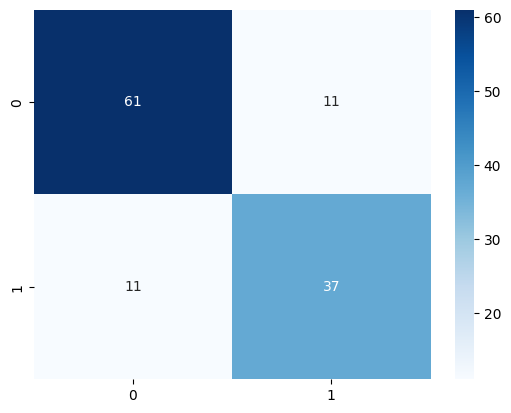

In [445]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_test, yp_test > 0.53)

tn, fp, fn, tp = matriz.ravel()

print(f"TN: {tn:2d}")
print(f"FP: {fp:2d}")
print(f"FN: {fn:2d}")
print(f"TP: {tp:2d}")

print()

accuracy = (tp + tn) / (tp + fp + fn + tn)
precision = tp / (tp + fp)
sensivity = tp / (tp + fn) # recall
specificity = tn / (tn + fp)
npv = tn / (tn + fn) # negative predictive value
f1 = 2 * (precision * sensivity) / (precision + sensivity) # f1-score

print(f"Exactitud     = {accuracy:.2f}")
print(f"Precision     = {precision:.2f}")
print(f"Sensibilidad  = {sensivity:.2f}")
print(f"Especificidad = {specificity:.2f}")
print(f"F1-Score      = {f1:.2f}")
print(f"NPV           = {npv:.2f}")

seaborn.heatmap(
    matriz,
    cmap="Blues",
    annot=True
)

Optimizando el umbral de decisión, podemos determinar que una decisión límite de 0.53 es más adecuada para predecir la supervivencia, es decir, nuestro modelo original podría suponer que arriba del 0.5 se da la supervivencia, pero en realidad, si el umbral es de 0.53, la matriz de confusión estará más balanceada entre los falsos positivos y los falsos negativos, aumentando bastante la sensibilidad y todas las métricas en general.

Esto significa que la predicción está sujeta a determinar la supervivencia si cruza el umbral de 0.53.

In [446]:
yp = (
    numpy.exp(X.dot(betas_opt)) /
    (1 + numpy.exp(X.dot(betas_opt)))
)

y=0.5 | x=0.0


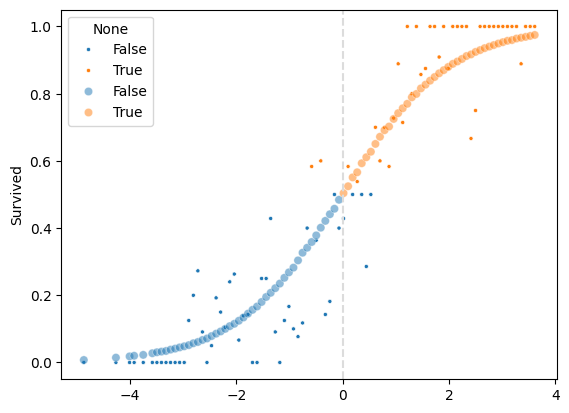

In [447]:
bins = pandas.cut(X.dot(betas_opt), bins=100)

promedios = y.groupby(bins, observed=False).mean()
promedios2 = pandas.Series(yp).groupby(bins, observed=False).mean()

centros = [
    intervalo.mid
    for intervalo in promedios.index
]

umbral = 0.5

seaborn.scatterplot(x=centros, y=promedios, hue=promedios > umbral, marker=".")
seaborn.scatterplot(x=centros, y=promedios2, hue=promedios2 > umbral, alpha=0.5)

# pyplot.axvline(0, color="gainsboro", ls="--", label="p=0.5")

print(f"y={umbral} | x={numpy.log(umbral/(1-umbral))}")

pyplot.axvline(
    numpy.log(umbral/(1-umbral)),
    color="gainsboro",
    ls="--",
    label=f"p={umbral}"
)

<Axes: ylabel='Survived'>

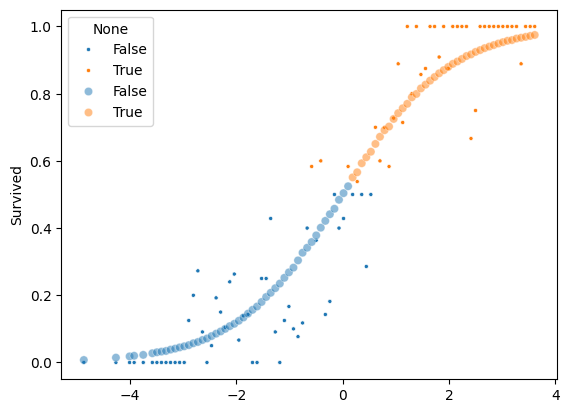

In [448]:
bins = pandas.cut(X.dot(betas_opt), bins=100)

promedios = y.groupby(bins, observed=False).mean()
promedios2 = pandas.Series(yp).groupby(bins, observed=False).mean()

centros = [
    intervalo.mid
    for intervalo in promedios.index
]

umbral = 0.53

seaborn.scatterplot(x=centros, y=promedios, hue=promedios > umbral, marker=".")
seaborn.scatterplot(x=centros, y=promedios2, hue=promedios2 > umbral, alpha=0.5)

y=0.53 | x=0.12014431184206341


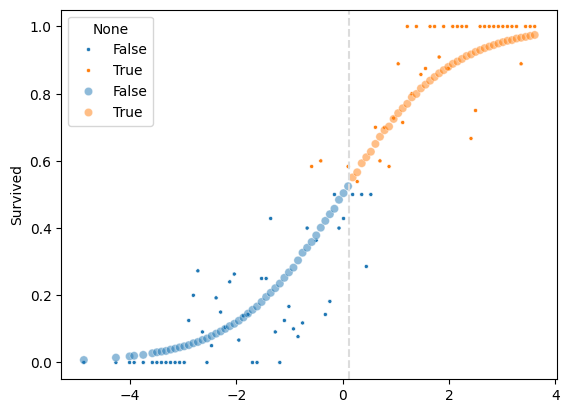

In [450]:
bins = pandas.cut(X.dot(betas_opt), bins=100)

promedios = y.groupby(bins, observed=False).mean()
promedios2 = pandas.Series(yp).groupby(bins, observed=False).mean()

centros = [
    intervalo.mid
    for intervalo in promedios.index
]

umbral = 0.53

seaborn.scatterplot(x=centros, y=promedios, hue=promedios > umbral, marker=".")
seaborn.scatterplot(x=centros, y=promedios2, hue=promedios2 > umbral, alpha=0.5)

# pyplot.axvline(0, color="gainsboro", ls="--", label="p=0.5")

print(f"y={umbral} | x={numpy.log(umbral/(1-umbral))}")

pyplot.axvline(
    numpy.log(umbral/(1-umbral)),
    color="gainsboro",
    ls="--",
    label=f"p={umbral}"
)

<Axes: ylabel='Count'>

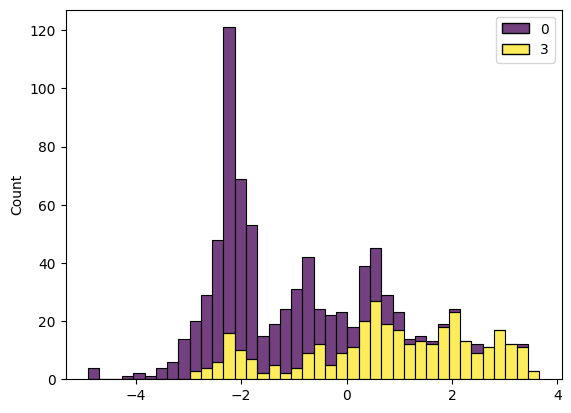

In [451]:
grupo = numpy.select(
    [
        (y == 0),
        (y == 1),
    ],
    [
        0,
        3,
    ]
)

seaborn.histplot(
    x=X.dot(betas_opt),
    hue=grupo,
    bins=40,
    multiple="stack",
    palette="viridis"
)

<Axes: ylabel='Count'>

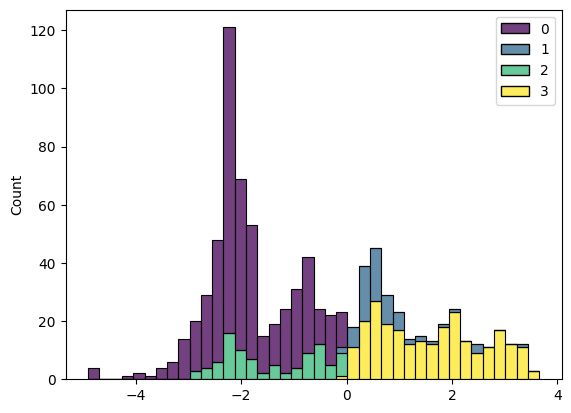

In [452]:
pred = yp > 0.5

grupo = numpy.select(
    [
        (pred == 0) & (y == 0),  # TN
        (pred == 1) & (y == 0),  # FP
        (pred == 0) & (y == 1),  # FN
        (pred == 1) & (y == 1),  # TP
    ],
    [
        0,
        1,
        2,
        3,
    ]
)

seaborn.histplot(
    x=X.dot(betas_opt),
    hue=grupo,
    bins=40,
    multiple="stack",
    palette="viridis"
)

<Axes: ylabel='Count'>

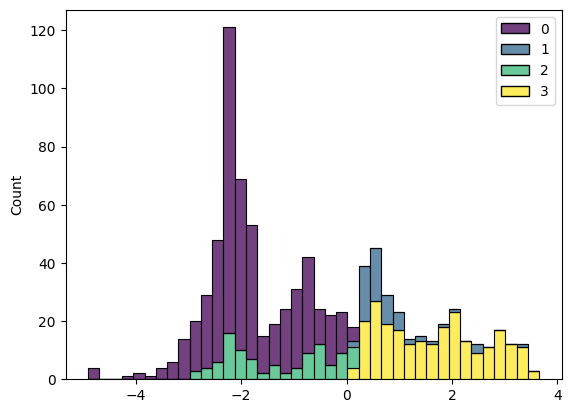

In [454]:
pred = yp > 0.53

grupo = numpy.select(
    [
        (pred == 0) & (y == 0),  # TN
        (pred == 1) & (y == 0),  # FP
        (pred == 0) & (y == 1),  # FN
        (pred == 1) & (y == 1),  # TP
    ],
    [
        0,
        1,
        2,
        3,
    ]
)

seaborn.histplot(
    x=X.dot(betas_opt),
    hue=grupo,
    bins=40,
    multiple="stack",
    palette="viridis"
)

<Axes: ylabel='Density'>

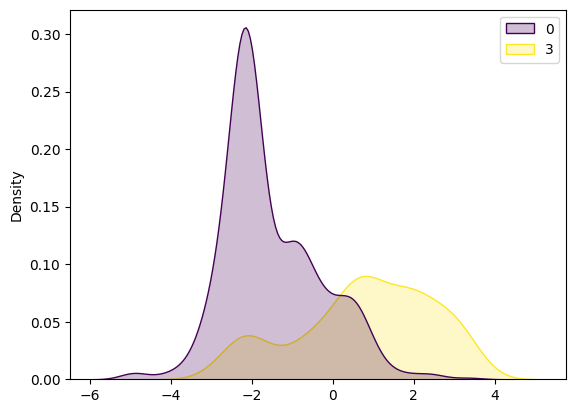

In [455]:
grupo = numpy.select(
    [
        (y == 0),
        (y == 1),
    ],
    [
        0,
        3,
    ]
)

seaborn.kdeplot(
    x=X.dot(betas_opt),
    hue=grupo,
    # bins=40,
    # multiple="stack",
    fill=True,
    palette="viridis"
)

<Axes: ylabel='Density'>

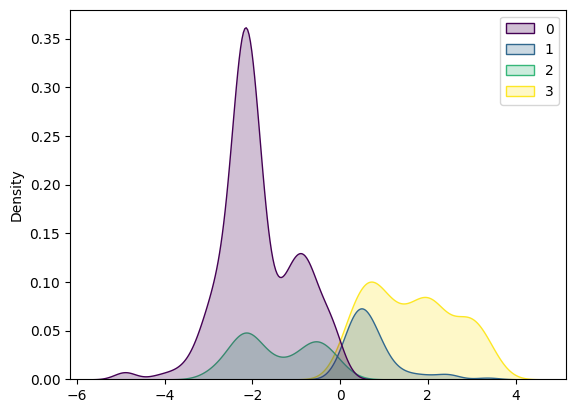

In [456]:
pred = yp > 0.5

grupo = numpy.select(
    [
        (pred == 0) & (y == 0),  # TN
        (pred == 1) & (y == 0),  # FP
        (pred == 0) & (y == 1),  # FN
        (pred == 1) & (y == 1),  # TP
    ],
    [
        0,
        1,
        2,
        3,
    ]
)

seaborn.kdeplot(
    x=X.dot(betas_opt),
    hue=grupo,
    # bins=40,
    # multiple="stack",
    fill=True,
    palette="viridis"
)

<Axes: ylabel='Density'>

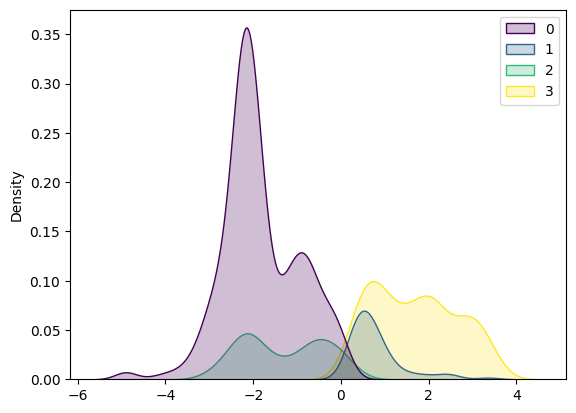

In [458]:
pred = yp > 0.53

grupo = numpy.select(
    [
        (pred == 0) & (y == 0),  # TN
        (pred == 1) & (y == 0),  # FP
        (pred == 0) & (y == 1),  # FN
        (pred == 1) & (y == 1),  # TP
    ],
    [
        0,
        1,
        2,
        3,
    ]
)

seaborn.kdeplot(
    x=X.dot(betas_opt),
    hue=grupo,
    # bins=40,
    # multiple="stack",
    fill=True,
    palette="viridis"
)

(0.0, 0.4)

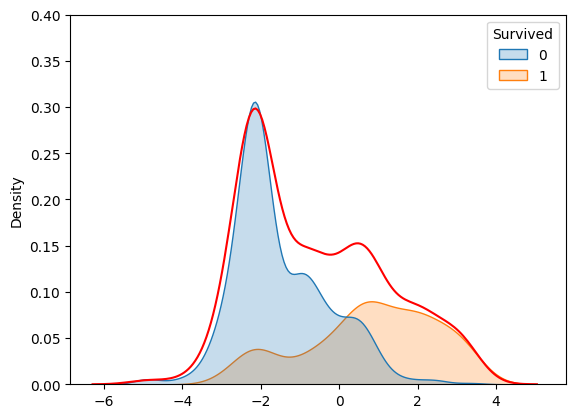

In [459]:
seaborn.kdeplot(x=X.dot(betas_opt), color="red")
seaborn.kdeplot(x=X.dot(betas_opt), hue=y, fill=True)
pyplot.ylim((0, 0.4))

<Axes: ylabel='Density'>

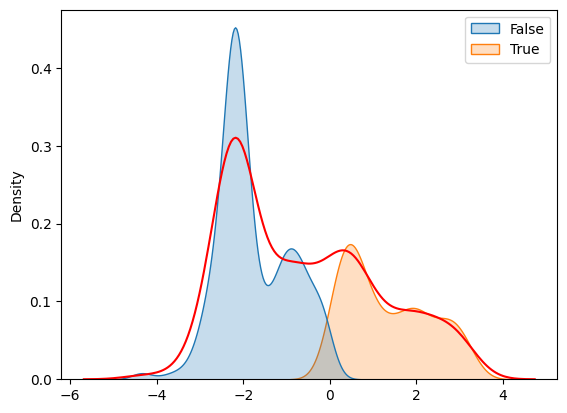

In [494]:
seaborn.kdeplot(x=X.dot(betas_opt), color="red")
seaborn.kdeplot(x=X.dot(betas_opt), hue=yp > 0.5, fill=True)
# pyplot.ylim((0, 0.4))

(0.0, 0.4)

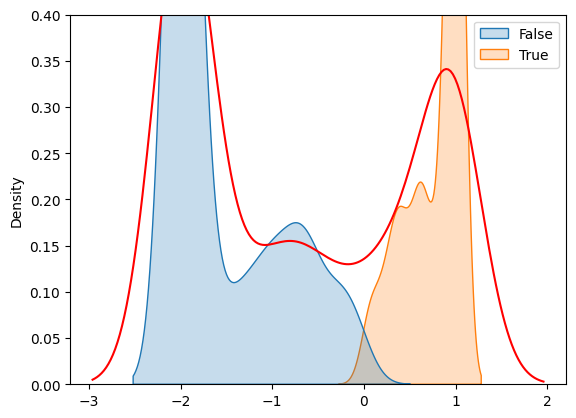

In [460]:
seaborn.kdeplot(x=X.dot(betas_opt).clip(-2, 1), color="red")
seaborn.kdeplot(x=X.dot(betas_opt).clip(-2, 1), hue=yp > 0.5, fill=True)
pyplot.ylim((0, 0.4))

(0.0, 0.4)

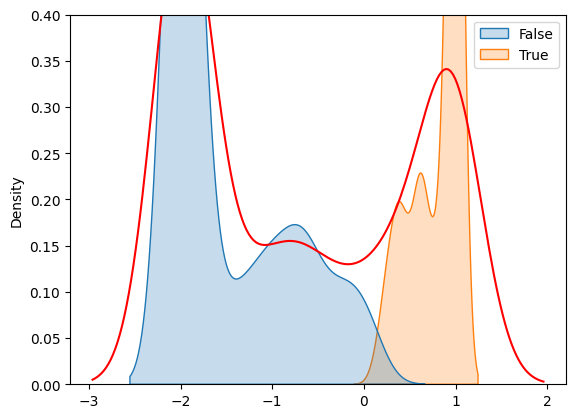

In [461]:
seaborn.kdeplot(x=X.dot(betas_opt).clip(-2, 1), color="red")
seaborn.kdeplot(x=X.dot(betas_opt).clip(-2, 1), hue=yp > 0.53, fill=True)
pyplot.ylim((0, 0.4))

In [462]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, yp)

np.float64(0.8563363478520223)

<Axes: >

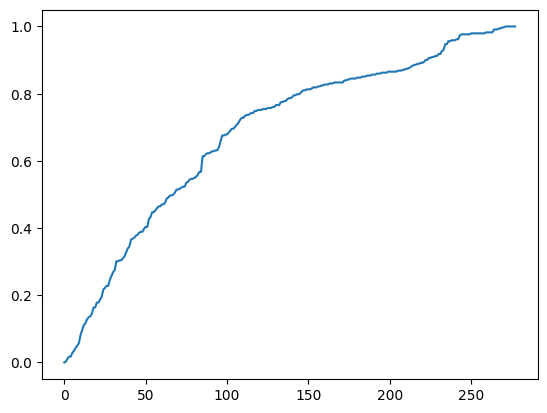

In [495]:
from sklearn.metrics import roc_curve

seaborn.lineplot(roc_curve(y, yp)[1])

### Comparación de las predicciones en baja dimensionalidad

Veamos la comparación entre las predicciones usando el umbral ingenuo del 0.5 y el optimizado a 0.37

Usaremos un PCA para graficar los dos componentes principales de las predicciones y poder llenar el espacio de predicción.

> Predicciones globales

In [470]:
yp = (
    numpy.exp(X.dot(betas_opt)) /
    (1 + numpy.exp(X.dot(betas_opt)))
)

pandas.DataFrame({
    "y": y,
    "yp": yp,
    "yp_bin": (yp > 0.5).astype(int),
    "yp_mej": (yp > 0.37).astype(int),
})

,y,yp,yp_bin,yp_mej
0,0,0.095809,0,0
1,1,0.925784,1,1
2,1,0.641803,1,1
3,1,0.931728,1,1
4,0,0.081612,0,0
...,...,...,...,...
886,0,0.269016,0,0
887,1,0.964648,1,1
888,0,0.470713,0,1
889,1,0.589645,1,1


> Matriz de los dos primeros componentes principales

In [471]:
from sklearn.decomposition import PCA

Xc = PCA(n_components=2).fit_transform(X)

pandas.DataFrame(Xc)

,0,1
0,0.175655,-0.555082
1,0.001123,0.912515
2,-0.791664,-0.472421
3,0.040005,0.719612
4,-0.972517,0.095218
...,...,...
886,-0.878207,-0.446008
887,-0.732306,-0.494815
888,2.121462,0.213018
889,-0.887238,-0.055778


(-2.0, 4.0)

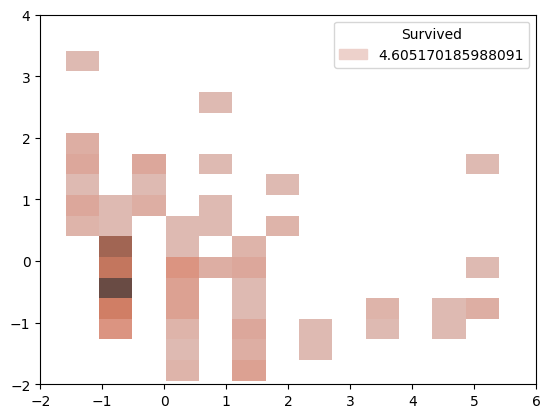

In [472]:
e = -(y * numpy.log((yp > 0.5).clip(0.01, 0.99)) + (1 - y) * numpy.log(1 - (yp > 0.5).clip(0.01, 0.99)))

seaborn.histplot(
    x=Xc[:, 0][e > 0.1],
    y=Xc[:, 1][e > 0.1],
    # size=e[e > 0.1],
    hue=e[e > 0.1],
    # palette="Blues",
    # sizes=(0, 100),
)

pyplot.xlim((-2, 6))
pyplot.ylim((-2, 4))

(-2.0, 4.0)

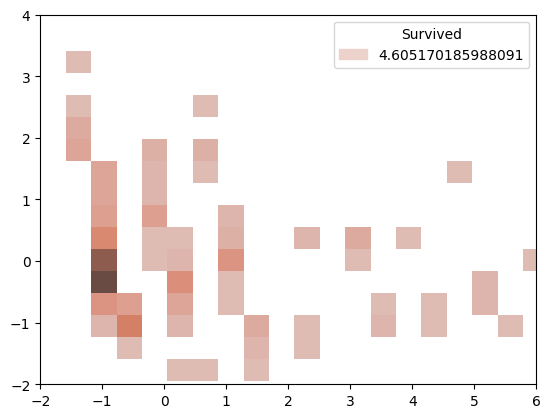

In [473]:
e = -(y * numpy.log((yp > 0.3).clip(0.01, 0.99)) + (1 - y) * numpy.log(1 - (yp > 0.3).clip(0.01, 0.99)))

seaborn.histplot(
    x=Xc[:, 0][e > 0.1],
    y=Xc[:, 1][e > 0.1],
    # size=e[e > 0.1],
    hue=e[e > 0.1],
    # palette="Blues",
    # sizes=(0, 100),
)

pyplot.xlim((-2, 6))
pyplot.ylim((-2, 4))

<Axes: >

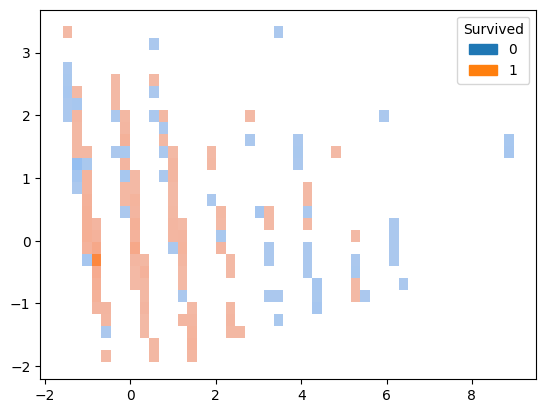

In [474]:
seaborn.histplot(x=Xc[:, 0], y=Xc[:, 1], hue=y)

<Axes: >

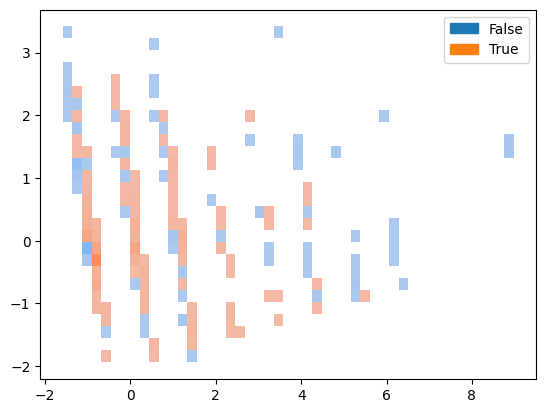

In [475]:
seaborn.histplot(x=Xc[:, 0], y=Xc[:, 1], hue=yp > 0.5)

<Axes: >

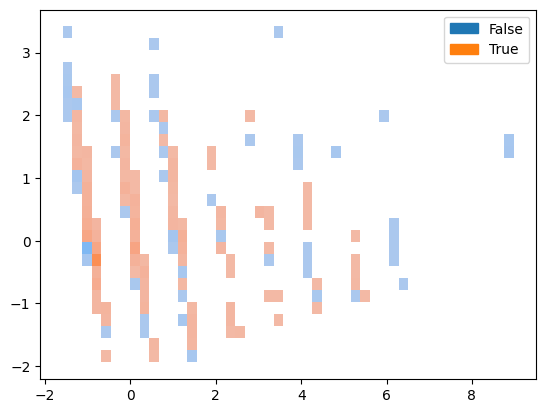

In [476]:
seaborn.histplot(x=Xc[:, 0], y=Xc[:, 1], hue=yp > 0.37)

In [482]:
n = 500

yp = (
    numpy.exp(X.dot(betas_opt)) /
    (1 + numpy.exp(X.dot(betas_opt)))
)

yp

array([0.09580934, 0.92578384, 0.64180318, 0.93172784, 0.08161236,
       0.09877421, 0.38310774, 0.09228551, 0.53150781, 0.87107946,
       0.86214153, 0.89454027, 0.12225577, 0.02142371, 0.71964839,
       0.71006513, 0.07588882, 0.26316549, 0.55474938, 0.62791424,
       0.22455791, 0.45228945, 0.71356425, 0.57507307, 0.56669916,
       0.25779858, 0.09877421, 0.3786264 , 0.62791424, 0.09877421,
       0.25448101, 0.94391978, 0.62791424, 0.10265585, 0.28315694,
       0.20614933, 0.09877421, 0.119077  , 0.59768723, 0.67462922,
       0.48756252, 0.82069421, 0.09877421, 0.85973074, 0.68845766,
       0.09877421, 0.08132793, 0.62791424, 0.06673498, 0.64779437,
       0.0660283 , 0.119077  , 0.89971841, 0.81170668, 0.26513306,
       0.57507307, 0.87150569, 0.09744871, 0.85234785, 0.03930735,
       0.11596997, 0.93918518, 0.39645474, 0.07179199, 0.32842101,
       0.06673498, 0.936587  , 0.1255073 , 0.39453625, 0.07056516,
       0.24059505, 0.35163865, 0.30579322, 0.08591856, 0.08860

<Axes: ylabel='Survived'>

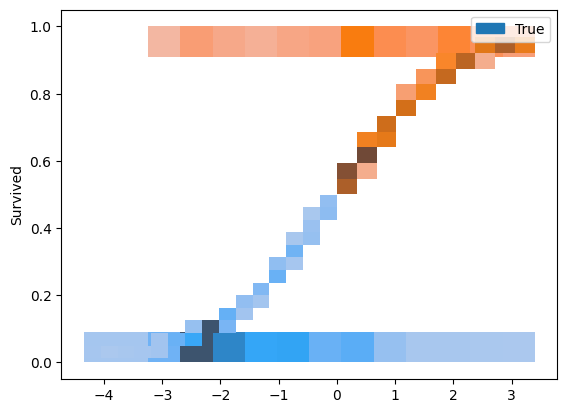

In [483]:
umbral = 0.5

seaborn.histplot(x=X.dot(betas_opt), y=y, hue=y)
seaborn.histplot(x=X.dot(betas_opt)[yp > umbral], y=yp[yp > umbral], hue=(yp > umbral)[yp > umbral], palette="Oranges")
seaborn.histplot(x=X.dot(betas_opt)[yp <= umbral], y=yp[yp <= umbral], hue=(yp <= umbral)[yp <= umbral])

<Axes: ylabel='Survived'>

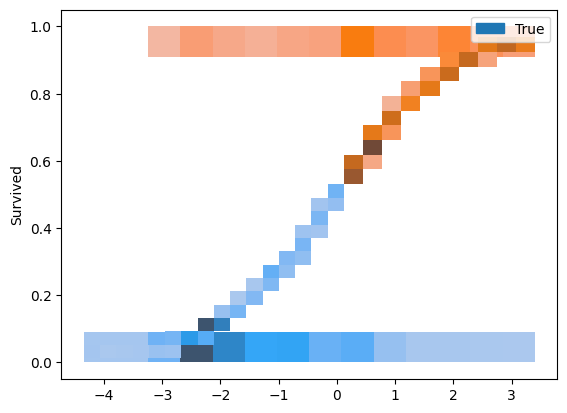

In [484]:
umbral = 0.53

seaborn.histplot(x=X.dot(betas_opt), y=y, hue=y)
seaborn.histplot(x=X.dot(betas_opt)[yp > umbral], y=yp[yp > umbral], hue=(yp > umbral)[yp > umbral], palette="Oranges")
seaborn.histplot(x=X.dot(betas_opt)[yp <= umbral], y=yp[yp <= umbral], hue=(yp <= umbral)[yp <= umbral])

<Axes: ylabel='Survived'>

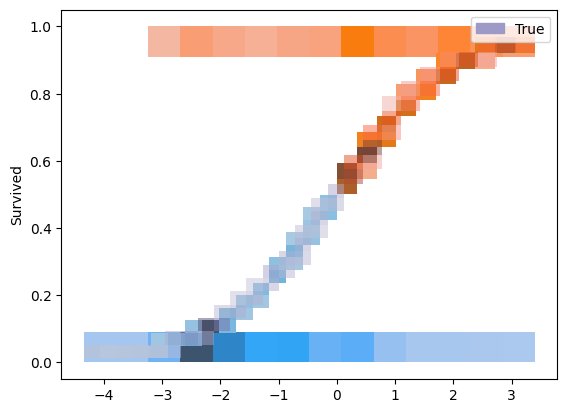

In [485]:
umbral1 = 0.5
umbral2 = 0.53

seaborn.histplot(x=X.dot(betas_opt), y=y, hue=y)
seaborn.histplot(x=X.dot(betas_opt)[yp > umbral1], y=yp[yp > umbral1], hue=(yp > umbral1)[yp > umbral1], palette="Oranges")
seaborn.histplot(x=X.dot(betas_opt)[yp <= umbral1], y=yp[yp <= umbral1], hue=(yp <= umbral1)[yp <= umbral1], palette="Blues")
seaborn.histplot(x=X.dot(betas_opt)[yp > umbral2], y=yp[yp > umbral2], hue=(yp > umbral2)[yp > umbral2], palette="Reds", alpha=0.5)
seaborn.histplot(x=X.dot(betas_opt)[yp <= umbral2], y=yp[yp <= umbral2], hue=(yp <= umbral2)[yp <= umbral2], palette="Purples", alpha=0.5)

<Axes: >

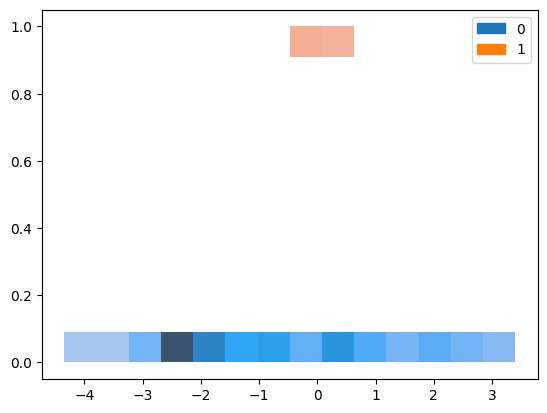

In [489]:
umbral1 = 0.5
umbral2 = 0.53

# seaborn.histplot(x=X.dot(betas_opt), y=y, hue=y)
seaborn.histplot(x=X.dot(betas_opt), y=(yp > umbral1).astype(int) - (yp > umbral2).astype(int), hue=(yp > umbral1).astype(int) - (yp > umbral2).astype(int))

<Axes: >

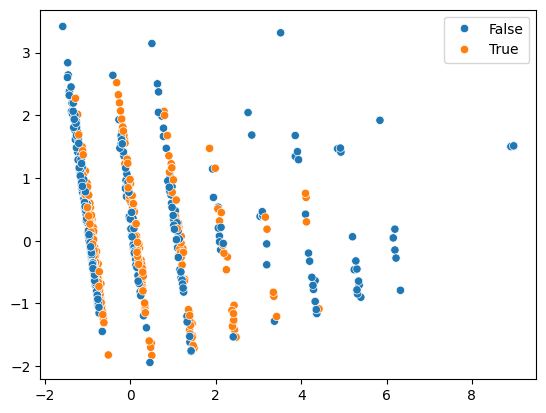

In [491]:
from sklearn.decomposition import PCA

Xc = PCA(n_components=2).fit_transform(X)

seaborn.scatterplot(x=Xc[:, 0], y=Xc[:, 1], hue=yp > 0.53)